# Titanic EDA + Insights

Exploratory analysis of the cleaned Titanic dataset. We profile the data, visualize key distributions and survival patterns, check correlations, and close with a quick feature-importance view to guide modeling.

## What’s Inside
- Data overview: shape, schema, target balance, missingness
- Univariate: numeric distributions and categorical counts
- Bivariate: survival by `Sex`, `Pclass`, `Embarked`, engineered features
- Correlations: numeric heatmap
- Quick feature importances (Gradient Boosting + preprocessing pipeline)


In [1]:
# --- Setup & Imports ---
from pathlib import Path
import sys
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: project preprocessing for feature importances later
try:
    from src.features import build_preprocess_pipeline
    from sklearn.pipeline import Pipeline
    from sklearn.ensemble import GradientBoostingClassifier
except Exception:
    build_preprocess_pipeline = None

# Read cleaned dataset
train_clean = pd.read_csv(ROOT / 'data' / 'processed' / 'train_clean.csv')

# Seaborn aesthetics
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

# Figure saving directory and auto-save hook
FIG_DIR = ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Figures will be saved to:', FIG_DIR)

import itertools
_eda_counter = itertools.count(1)
_orig_show = plt.show
def _show_and_save(*args, **kwargs):
    i = next(_eda_counter)
    name = f'eda_{i:02d}.png'
    try:
        ax = plt.gca()
        t = ax.get_title()
        if t:
            safe = ''.join(c for c in t.lower().replace(' ', '_') if c.isalnum() or c in '._-')
            if safe:
                name = f'{safe}.png'
    except Exception:
        pass
    try:
        plt.gcf().savefig(FIG_DIR / name, dpi=150, bbox_inches='tight')
    except Exception:
        pass
    return _orig_show(*args, **kwargs)
plt.show = _show_and_save

print('Rows, Cols:', train_clean.shape)
train_clean.head(3)


Figures will be saved to: C:\Users\hasti_aksoy\OneDrive\Desktop\Titanic\reports\figures
Rows, Cols: (891, 16)


,Survived,Pclass,Sex,Age,SibSp,Parch,FamilySize,IsAlone,Fare,Embarked,Deck,HasCabin,TicketGroupSize,TicketPrefix,Title,PassengerId
0,0,3,male,22.0,1,0,2,0,7.2500,S,U,0,1,A,Mr,1
1,1,1,female,38.0,1,0,2,0,71.2833,C,C,1,1,PC,Mrs,2
2,1,3,female,26.0,0,0,1,1,7.9250,S,U,0,1,STONO,Miss,3


## Target Balance & Missingness
Quick look at target distribution and fraction of missing values per column (post-cleaning it should be low, but we verify).


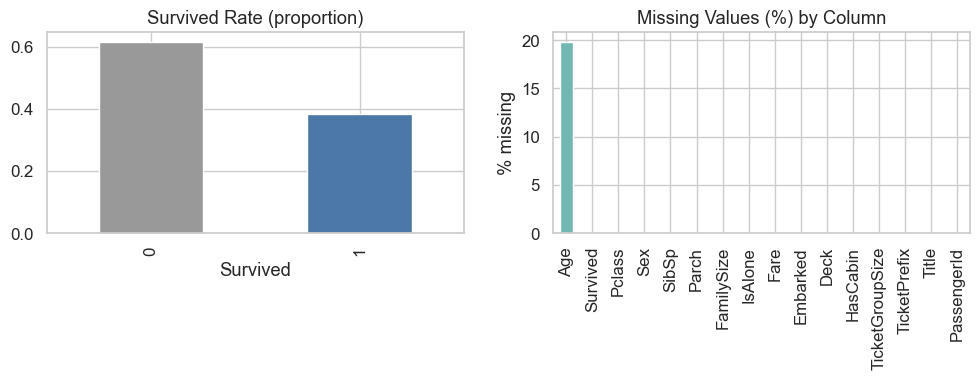

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Target balance
train_clean['Survived'].value_counts(normalize=True).sort_index().plot(
    kind='bar', ax=axes[0], color=['#999', '#4c78a8']
)
axes[0].set_title('Survived Rate (proportion)')
axes[0].set_xlabel('Survived')

# Missingness
(train_clean.isna().mean() * 100).sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='#72b7b2'
)
axes[1].set_title('Missing Values (%) by Column')
axes[1].set_ylabel('% missing')
plt.tight_layout(); plt.show() 

## Univariate Distributions
Distributions for key numeric features. Helps spot skew, outliers, and typical ranges.


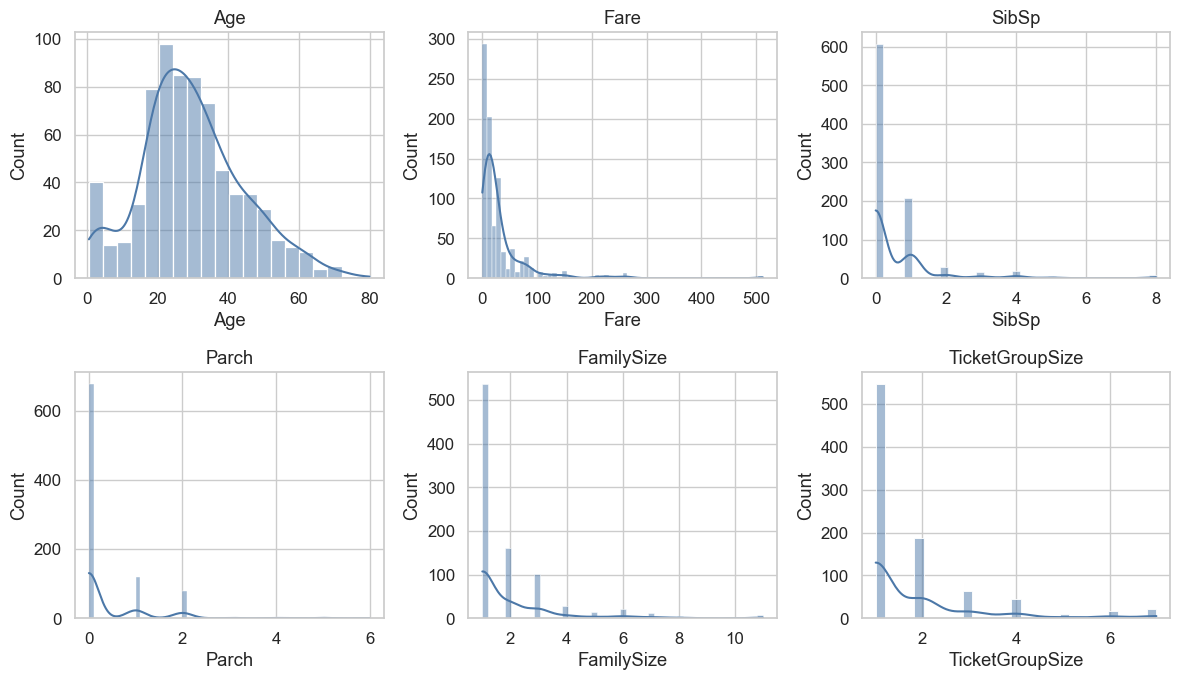

In [3]:
num_cols = ['Age','Fare','SibSp','Parch','FamilySize','TicketGroupSize']
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.histplot(train_clean[col], kde=True, ax=axes[i], color='#4c78a8')
    axes[i].set_title(col)
plt.tight_layout(); plt.show()


## Survival by Key Categories
Average survival rate grouped by `Sex`, `Pclass`, and `Embarked`.


C:\Users\hasti_aksoy\AppData\Local\Temp\ipykernel_33316\980191766.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_clean, x='Sex', y='Survived', ci=None, ax=axes[0])
C:\Users\hasti_aksoy\AppData\Local\Temp\ipykernel_33316\980191766.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_clean, x='Pclass', y='Survived', ci=None, ax=axes[1])
C:\Users\hasti_aksoy\AppData\Local\Temp\ipykernel_33316\980191766.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_clean, x='Embarked', y='Survived', ci=None, ax=axes[2])


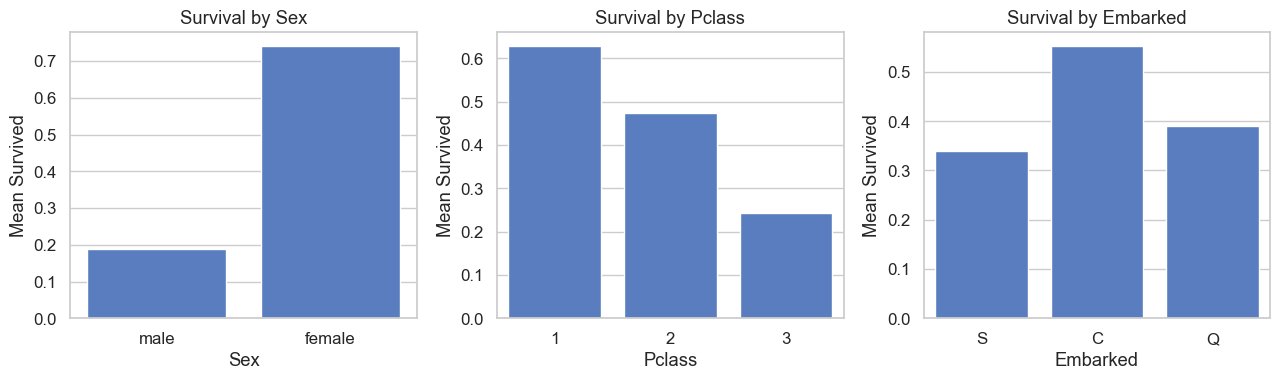

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.barplot(data=train_clean, x='Sex', y='Survived', ci=None, ax=axes[0])
axes[0].set_title('Survival by Sex')
sns.barplot(data=train_clean, x='Pclass', y='Survived', ci=None, ax=axes[1])
axes[1].set_title('Survival by Pclass')
sns.barplot(data=train_clean, x='Embarked', y='Survived', ci=None, ax=axes[2])
axes[2].set_title('Survival by Embarked')
for ax in axes: ax.set_ylabel('Mean Survived')
plt.tight_layout(); plt.show()


## Continuous vs. Survival
Age and Fare vs survival as violin/box plots to inspect distributional shifts.


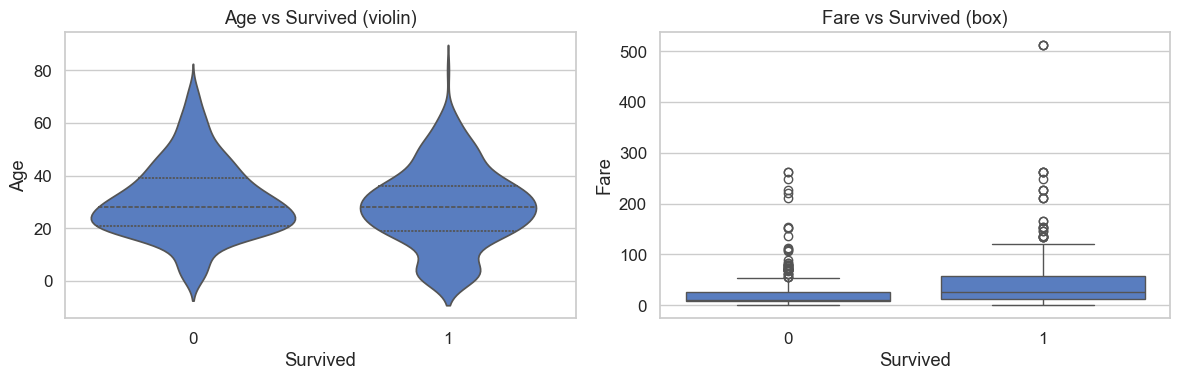

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.violinplot(data=train_clean, x='Survived', y='Age', ax=axes[0], inner='quartile')
axes[0].set_title('Age vs Survived (violin)')
sns.boxplot(data=train_clean, x='Survived', y='Fare', ax=axes[1])
axes[1].set_title('Fare vs Survived (box)')
plt.tight_layout(); plt.show()


## Engineered Features vs. Survival
Check how engineered features relate to outcomes.


C:\Users\hasti_aksoy\AppData\Local\Temp\ipykernel_33316\1139992213.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_clean, x='IsAlone', y='Survived', ci=None, ax=axes[0])
C:\Users\hasti_aksoy\AppData\Local\Temp\ipykernel_33316\1139992213.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_clean, x='HasCabin', y='Survived', ci=None, ax=axes[1])


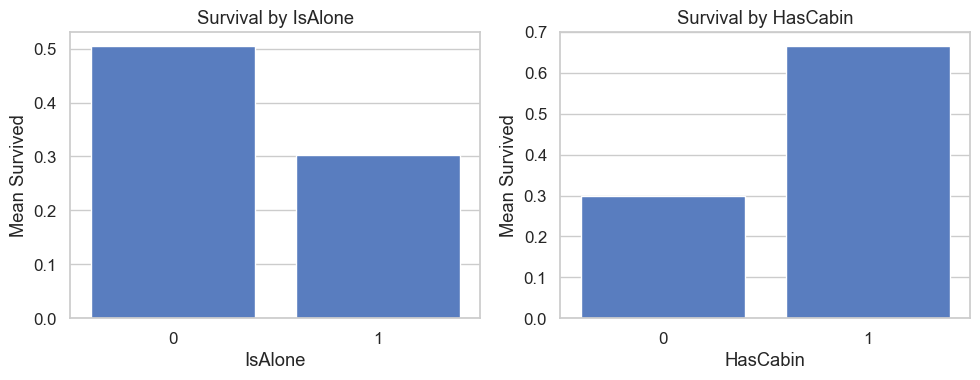

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.barplot(data=train_clean, x='IsAlone', y='Survived', ci=None, ax=axes[0])
axes[0].set_title('Survival by IsAlone')
sns.barplot(data=train_clean, x='HasCabin', y='Survived', ci=None, ax=axes[1])
axes[1].set_title('Survival by HasCabin')
for ax in axes: ax.set_ylabel('Mean Survived')
plt.tight_layout(); plt.show()


## Numeric Correlations
Correlation heatmap across numeric features (incl. target) to spot linear relationships and potential redundancies.


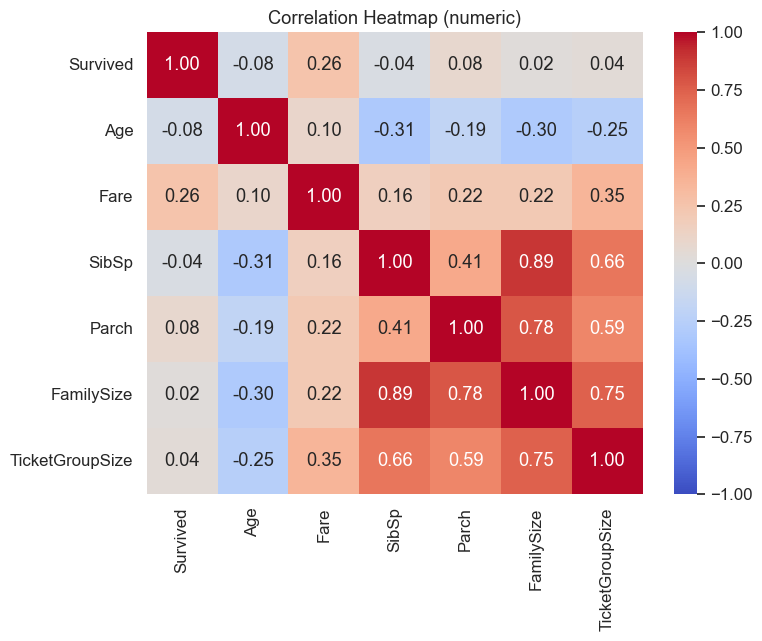

In [7]:
num_for_corr = ['Survived','Age','Fare','SibSp','Parch','FamilySize','TicketGroupSize']
corr = train_clean[num_for_corr].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (numeric)')
plt.show()


## Quick Feature Importances (GB)
Fit a small Gradient Boosting model with the project’s preprocessing to get a rough ranking of features. This is not a substitute for full modeling, but it helps prioritize signals.


,feature,importance
27,Title_Mr,0.449094
1,Fare,0.104628
10,Pclass_3,0.085011
0,Age,0.062280
5,TicketGroupSize,0.058813
29,Title_Rare,0.051450
4,FamilySize,0.044921
7,HasCabin,0.016061
58,TicketPrefix_SWPP,0.013486
57,TicketPrefix_STONO,0.011845


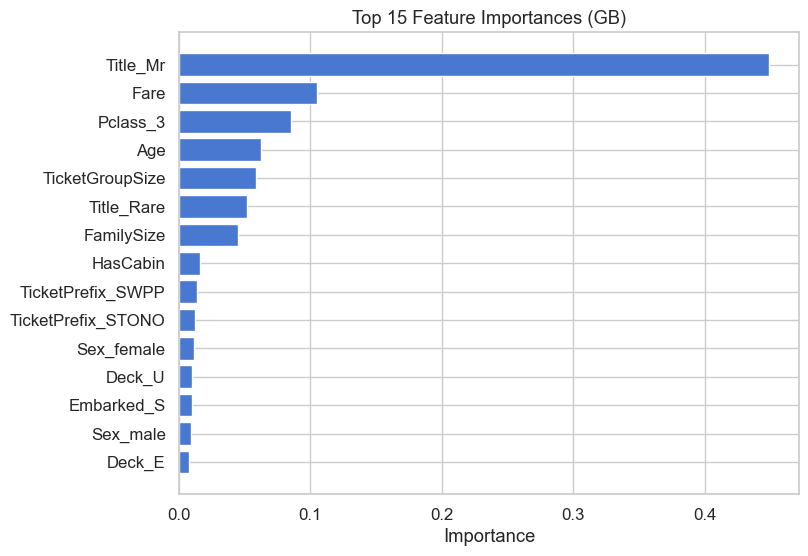

In [8]:
if build_preprocess_pipeline is not None:
    X = train_clean.drop(columns=['Survived','PassengerId'])
    y = train_clean['Survived']
    pre = build_preprocess_pipeline(train_clean)
    gb = GradientBoostingClassifier(random_state=42)
    pipe = Pipeline([('pre', pre), ('clf', gb)])
    pipe.fit(X, y)
    pre_step = pipe.named_steps['pre']
    gb_clf = pipe.named_steps['clf']
    try:
        fn = pre_step.get_feature_names_out()
    except Exception:
        fn = [f'f{i}' for i in range(len(gb_clf.feature_importances_))]
    fi = pd.DataFrame({'feature': fn, 'importance': gb_clf.feature_importances_})\
         .sort_values('importance', ascending=False)
    display(fi.head(15))
    plt.figure(figsize=(8,6))
    topk = fi.head(15)
    plt.barh(topk['feature'], topk['importance'])
    plt.gca().invert_yaxis()
    plt.title('Top 15 Feature Importances (GB)')
    plt.xlabel('Importance')
    plt.show()
else:
    print('build_preprocess_pipeline not available; skipping feature importances.')
